In [167]:
# authors
# Nguyen Van A, ...

In [168]:
# warning:
# only custmoze the 3-4-5 blocks

In [169]:
# library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import math

In [170]:
# input your data here
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Colab Notebooks/GTNC/sample_data'


COL_pv = ['date', 'opn', 'cls', 'low', 'high', 'nsh', 'vol', 'adj']

stk = 's2'
A = np.load(f"{path}/{stk}.npy", allow_pickle=True)

# 4. Gán tên cột bằng cách tạo DataFrame
df = pd.DataFrame(A, columns=COL_pv)

if 'date' in df.columns:
    # Cách xử lý tùy thuộc format gốc, đây là cách tổng quát:
    df['date'] = pd.to_datetime(df['date'].astype(str).str.replace(r'\.0$', '', regex=True), format='%Y%m%d', errors='coerce')
    df.set_index('date', inplace=True)


P = df['cls'].values
V = df['vol'].values
P_adj = df['adj'].values


print("--- Check DataFrame ---")
print(df.head())
print(f"\nShape dữ liệu: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Check DataFrame ---
              opn    cls    low   high         nsh      vol    adj
date                                                              
2024-04-19  80.80  79.70  79.70  81.31   7851100.0   887.18  81.75
2024-04-22  80.43  80.65  79.63  81.45   2505218.0   276.69  79.70
2024-04-23  81.09  82.11  80.36  82.84   4233700.0   472.70  80.65
2024-04-24  83.06  87.81  82.77  87.81  10945700.0  1299.24  82.11
2024-04-25  89.57  90.08  89.13  93.59   9215500.0  1158.69  87.81

Shape dữ liệu: (242, 7)


In [171]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from google.colab import drive

npy_files = glob.glob(f"{path}/*.npy")
print(f"[*] Tìm thấy {len(npy_files)} file .npy trong thư mục.")
h = 15
all_X = []
all_y = []

print("[*] Đang xử lý và gộp dữ liệu từ các file...")
for file in npy_files:
    try:
        # Load data
        A = np.load(file, allow_pickle=True)
        df = pd.DataFrame(A, columns=COL_pv)

        # Chỉ lấy P (Close) và V (Volume)
        P = df['cls'].values.astype(float)
        V = df['vol'].values.astype(float)
        n = len(P)

        if n <= h:
            continue # Bỏ qua nếu data quá ngắn

        # Tính toán Features cơ bản (Đã chuẩn hóa)
        returns = np.zeros(n)
        vol_changes = np.zeros(n)
        for i in range(1, n):
            returns[i] = P[i] / P[i-1] - 1
            vol_ratio = V[i] / (V[i-1] + 1e-8)
            vol_changes[i] = np.log(vol_ratio)

        # Kẹp nhiễu
        returns = np.clip(returns, -0.15, 0.15)
        vol_changes = np.clip(vol_changes, -3.0, 3.0)

        # Cắt Window
        for j in range(h, n - 1):
            feat_ret = returns[j-h+1 : j+1]
            feat_vol = vol_changes[j-h+1 : j+1]
            all_X.append(np.column_stack((feat_ret, feat_vol)))
            all_y.append(returns[j+1]) # Target là Return của ngày tiếp theo

    except Exception as e:
        print(f"  -> Lỗi khi xử lý {file}: {e}")

X_train_full = np.array(all_X)
y_train_full = np.array(all_y)

print(f"\n[+] Tổng hợp thành công!")
print(f" -> Kích thước Input X: {X_train_full.shape} (Có {X_train_full.shape[0]} mẫu)")
print(f" -> Kích thước Target y: {y_train_full.shape}")

# 3. BUILD MÔ HÌNH SIGN-MAGNITUDE (Kiến trúc của bạn)
print("\n[*] Đang khởi tạo mô hình Sign-Magnitude...")
LSTM_L2_FACTOR = 1e-5
lstm_units = [64, 32]
dropout = 0.3

inputs = layers.Input(shape=(h, 2))
x = inputs

# --- LSTM Backbone ---
for layer_idx, units in enumerate(lstm_units):
    return_sequences = layer_idx < len(lstm_units) - 1
    x = layers.LSTM(
        units,
        return_sequences=return_sequences,
        kernel_regularizer=regularizers.l2(LSTM_L2_FACTOR),
        recurrent_regularizer=regularizers.l2(LSTM_L2_FACTOR),
    )(x)
    if dropout > 0 and return_sequences:
        x = layers.Dropout(dropout)(x)

encoded = x

# --- Sign & Magnitude Heads ---
sign_prob = layers.Dense(1, activation="sigmoid", name="sign_prob")(encoded)
sign_centered = layers.Rescaling(scale=2.0, offset=-1.0, name="sign_centered")(sign_prob)

magnitude_raw = layers.Dense(1, activation="softplus", name="magnitude_raw")(encoded)
magnitude = layers.Lambda(tf.math.expm1, name="magnitude")(magnitude_raw)

signed_prediction = layers.Multiply(name="signed_prediction")([sign_centered, magnitude])

global_model = keras.Model(inputs=inputs, outputs=signed_prediction)
global_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss="huber"
)

# 4. HUẤN LUYỆN (TRAIN) VÀ LƯU MÔ HÌNH
# Dùng EarlyStopping để không bị overfit
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

print("\n[*] BẮT ĐẦU HUẤN LUYỆN...")
global_model.fit(
    X_train_full, y_train_full,
    epochs=50,
    batch_size=256,
    validation_split=0.2, # Lấy 20% lượng mẫu làm test
    shuffle=True,         # Xáo trộn dữ liệu vì ta đã gộp nhiều mã
    callbacks=[early_stop],
    verbose=1
)

# Lưu lại vào ổ Drive của bạn luôn
save_path = '/content/drive/MyDrive/Colab Notebooks/GTNC/global_signmag_model.keras'
global_model.save(save_path)
print(f"\n[+] XONG! Mô hình Global đã được lưu an toàn tại: {save_path}")

[*] Tìm thấy 30 file .npy trong thư mục.
[*] Đang xử lý và gộp dữ liệu từ các file...

[+] Tổng hợp thành công!
 -> Kích thước Input X: (6780, 15, 2) (Có 6780 mẫu)
 -> Kích thước Target y: (6780,)

[*] Đang khởi tạo mô hình Sign-Magnitude...

[*] BẮT ĐẦU HUẤN LUYỆN...
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 9.6156e-04 - val_loss: 7.9781e-04
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 6.9139e-04 - val_loss: 5.7512e-04
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 5.0276e-04 - val_loss: 4.2222e-04
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 3.7317e-04 - val_loss: 3.1815e-04
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 2.8602e-04 - val_loss: 2.4986e-04
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 2.2931e-04 - val_loss: 2.0535e-04
Ep

In [ ]:
# customize your prediction
def prediction(df, h=15):
    """
    Hàm dự đoán sử dụng mô hình Global Sign-Magnitude.
    Đã fix lỗi 'expm1' khi load model Keras.
    """
    import numpy as np
    import pandas as pd
    import tensorflow as tf
    from tensorflow import keras

    def truncate(u):
        if u < -0.07: return -0.07
        elif u > 0.07: return 0.07
        return u

    # 1. TRÍCH XUẤT P VÀ V TỪ DATAFRAME
    df_copy = df.copy()

    P = df_copy['cls'].values.astype(float)
    V = df_copy['vol'].values.astype(float)

    n = len(P)
    Q = [0] * n

    # 2. TIỀN XỬ LÝ
    returns = np.zeros(n)
    vol_changes = np.zeros(n)
    for i in range(1, n):
        returns[i] = P[i] / P[i-1] - 1
        vol_ratio = V[i] / (V[i-1] + 1e-8)
        vol_changes[i] = np.log(vol_ratio)

    returns = np.clip(returns, -0.15, 0.15)
    vol_changes = np.clip(vol_changes, -3.0, 3.0)

    # 3. XÂY DỰNG SEQUENCES
    X = []
    valid_indices = []

    for j in range(h, n - 1):
        feat_ret = returns[j-h+1 : j+1]
        feat_vol = vol_changes[j-h+1 : j+1]
        X.append(np.column_stack((feat_ret, feat_vol)))
        valid_indices.append(j)

    if len(X) == 0:
        return Q

    X = np.array(X)

    # 4. TẢI MÔ HÌNH VÀ DỰ ĐOÁN
    model_path = '/content/drive/MyDrive/Colab Notebooks/GTNC/global_signmag_model.keras'

    # => FIX LỖI Ở ĐÂY: Khai báo rõ hàm expm1 cho Keras hiểu
    model = keras.models.load_model(
        model_path,
        custom_objects={'expm1': tf.math.expm1},
        compile=False
    )

    preds = model(X, training=False).numpy()

    for idx, j in enumerate(valid_indices):
        Q[j] = truncate(preds[idx][0])

    return Q

In [173]:
# keep the core function unchanged
def target(P, V):
    n, Q = len(P), [0]
    for i in range(1, n):
        Q.append(P[i] / P[i -1] - 1)
    return Q

def evaluate(p, t, dspl=False):
    p, t = p[1 :], t[1 :]
    n, e, f = len(t), [], []
    for i in range(1, n):
        e.append(t[i] - p[i - 1])
        f.append(t[i])
    den = np.nanquantile(np.abs(e), 0.5) + 0.5 * np.nanquantile(np.abs(e), 0.9)
    num = np.nanquantile(np.abs(f), 0.5) + 0.5 * np.nanquantile(np.abs(f), 0.9)
    if dspl == True:
        print(f"\n\tbase = {round(num, 3)}  |  abs = {round(den, 3)}  |  rel = {round(1 - den / num, 3)}\n")
        plt.hist(e, edgecolor='black')
        plt.show()
    else:
        return den, 1 - den / num


	base = 0.021  |  abs = 0.021  |  rel = 0.005



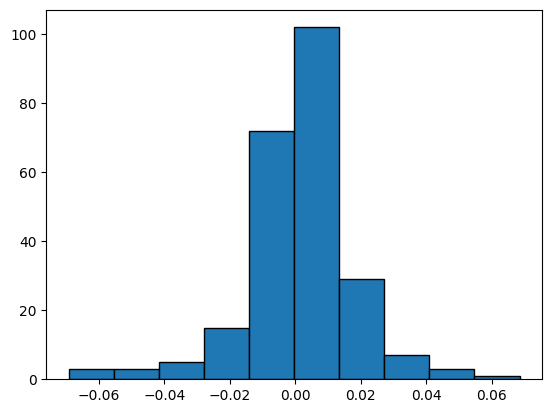

In [174]:
# execute
# Note that score "rel" > 0 shows that there are good signals, "abs" < 0.005 is good signal
p, t = prediction(df, 15), target(P, V)
evaluate(p, t, True)